In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/puneet6060/intel-image-classification


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU:", len(tf.config.list_physical_devices('GPU')))

2026-04-15 23:35:24.230486: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776296124.390598      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776296124.441053      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776296124.814466      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776296124.814503      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776296124.814506      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU: 2


In [3]:
TRAIN_DIR   = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train"
TEST_DIR    = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test"
CLASSES     = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 150
BATCH_SIZE  = 32
AUTOTUNE    = tf.data.AUTOTUNE

print("Classes:", CLASSES)
print("Train dir exists:", __import__('os').path.exists(TRAIN_DIR))
print("Test dir exists:",  __import__('os').path.exists(TEST_DIR))

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train dir exists: True
Test dir exists: True


In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,                
    label_mode='int',
    validation_split=0.15,        
    subset='training',
    seed=42  # seed is set here 
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,
    label_mode='int',
    validation_split=0.15,
    subset='validation',
    seed=42 # seed is set here 
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=64,
    label_mode='int',
    shuffle=False
)

def augment(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)   
    return image, label                              

def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(augment).prefetch(AUTOTUNE)
val_ds   = val_ds.map(normalize).prefetch(AUTOTUNE)
test_ds  = test_ds.map(normalize).prefetch(AUTOTUNE)

for img, lbl in train_ds.take(1):
    print("Image shape:", img.shape)
    print("Label shape:", lbl.shape)

Found 14034 files belonging to 6 classes.
Using 11929 files for training.


I0000 00:00:1776296177.742917      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776296177.748854      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 14034 files belonging to 6 classes.
Using 2105 files for validation.
Found 3000 files belonging to 6 classes.
Image shape: (64, 150, 150, 3)
Label shape: (64,)


In [5]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),

    # Classifier
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,494 (1.23 MB)

 Trainable params: 322,534 (1.23 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5,                      
        verbose=1, min_lr=1e-6
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8,  
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    epochs=50,                           
    validation_data=val_ds,
    callbacks=callbacks
)

test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

Epoch 1/50


I0000 00:00:1776296188.679814     132 service.cc:152] XLA service 0x7de658107de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776296188.679849     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776296188.679852     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776296189.466519     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-15 23:36:34.244125: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-15 23:36:34.407070: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-15 23:36:36.973245: E external/local_xl

  1/187 ━━━━━━━━━━━━━━━━━━━━ 1:02:11 20s/step - accuracy: 0.1562 - loss: 3.0983

I0000 00:00:1776296205.117094     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


186/187 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.4110 - loss: 1.6643

2026-04-15 23:37:09.811778: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-15 23:37:09.963937: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-15 23:37:10.480892: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-15 23:37:10.627812: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-15 23:37:11.643249: E external/local_xla/xla/stream_

187/187 ━━━━━━━━━━━━━━━━━━━━ 61s 218ms/step - accuracy: 0.4119 - loss: 1.6608 - val_accuracy: 0.1639 - val_loss: 4.4469 - learning_rate: 0.0010
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - accuracy: 0.6369 - loss: 0.9216 - val_accuracy: 0.1644 - val_loss: 4.2319 - learning_rate: 0.0010
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 25s 133ms/step - accuracy: 0.7190 - loss: 0.7256 - val_accuracy: 0.4204 - val_loss: 2.0792 - learning_rate: 0.0010
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 27s 142ms/step - accuracy: 0.7641 - loss: 0.6289 - val_accuracy: 0.7691 - val_loss: 0.7300 - learning_rate: 0.0010
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 28s 147ms/step - accuracy: 0.7937 - loss: 0.5599 - val_accuracy: 0.7373 - val_loss: 0.8592 - learning_rate: 0.0010
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 26s 140ms/step - accuracy: 0.8114 - loss: 0.5074 - val_accuracy: 0.8238 - val_loss: 0.4837 - learning_rate: 0.0010
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 26s 140ms/step - accuracy: 0.8269 - loss:

Saved: joel_model.keras


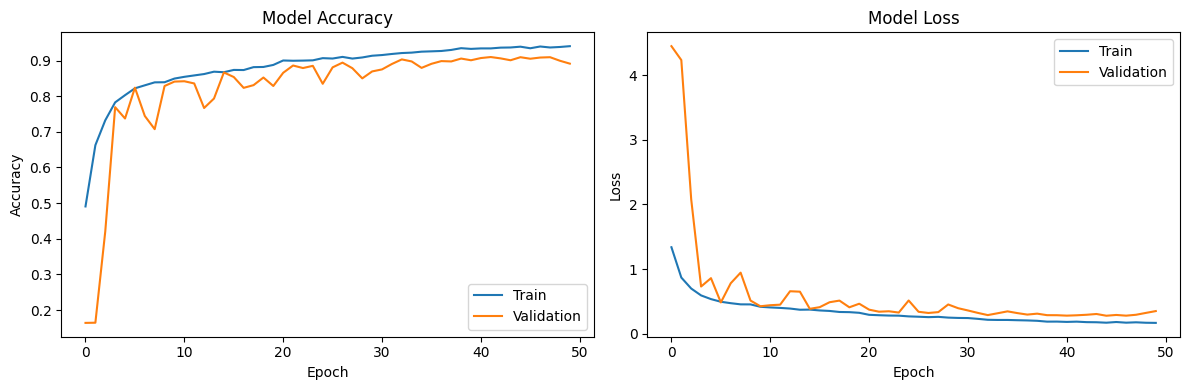

In [7]:
model.save("joel_model.keras")
print("Saved: joel_model.keras")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('tf_training_curves.png', dpi=150)
plt.show()

In [8]:
from IPython.display import FileLink

print(FileLink('joel_model.keras'))
print(FileLink('tf_training_curves.png'))

/kaggle/working/joel_model.keras
/kaggle/working/tf_training_curves.png
